# txt to csv

In [1]:
!pip install camel_tools

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 1.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 16.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.1 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.3/122.3 kB 9.8 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13781 sha256=24284c8c9edc8f3ee6f8b28bdd620511f2081756a9ca4742224d35b76f62359a
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following 

In [2]:
import pandas as pd
import camel_tools
import nltk

In [57]:
#1 -> 15
#2 -> 20
#3 -> 19
#4 -> 
#5 - >
import os
import pandas as pd

folder_path = "/kaggle/input/datasets/ranagaber1111/rewayat/everything_zipped/zipped_3"
records = []

for filename in sorted(os.listdir(folder_path)):
    if filename.endswith(".txt"):
        file_path = os.path.join(folder_path, filename)
        
        with open(file_path, "r", encoding="utf-8-sig") as file:
            lines = [line.strip() for line in file.readlines() if line.strip()]
            
        for i in range(0, len(lines), 10):
            chunk = lines[i : i + 10]
            
            chunk_text = "\n".join(chunk)
            
            records.append({
                "source_file": filename,
                "chunk_index": (i // 10) + 1,
                "text": chunk_text
            })

df = pd.DataFrame(records)
print(df.head())

          source_file  chunk_index  \
0  al_qa2d_2_ch_1.txt            1   
1  al_qa2d_2_ch_1.txt            2   
2  al_qa2d_2_ch_1.txt            3   
3  al_qa2d_2_ch_1.txt            4   
4  al_qa2d_2_ch_1.txt            5   

                                                text  
0  ☰\nRed Rectangle\nروائيون وروائيات\nقصص رومانس...  
1  قصص بوليسية\nقصص خيال علمي\nورشة الكتابة الابد...  
2  ابتسم بمرح و هو بيقعد جنبها ع السجاده: اه و ال...  
3  عابد إبتسم بحب و ضرب بكفه بخفه على خد ادم: يا ...  
4  فاطمه ربعت قصاده بحب و قربت شويه و مسكت إيديه ...  


In [36]:
print(df.loc[2,'text'])

بصت لهمس وحضنتها هي كمان بود: فكرة مين فيكم دي؟
همس بصت بمرح لسيف اللي ضحك: بتبيعي وقتي انتِ.
ضحكوا فكمل بتبرير: انتِ عارفاني من زمان ما بحبش أعرفكم ميعاد نزولي ده مش جديد عليا.
سلوى بعتاب: يعني قلت هتتجوز تعرفنا بقى نستعد لاستقبالكم، حتى يا أخي ننظف الجناح مثلا.
سيف بص لعواطف: أوضتي مش نظيفة؟
ابتسمت بثقة: بتلمع.
ابتسملها وبص لأمه: عارف انها دايما نظيفة عايزة تستعدي لايه بقى؟ ولا عايزة تفضلي قلقانة من أول ما نتحرك من البيت لحد ما نوصل لهنا؟ المهم بابا فين؟
عز كان نازل وراه فقال بمزاح: لسه فاكر تسأل عن أبوك؟
قرب منه وحضنوا بعض بلهفة وسيف علق بحب: انت الخير والبركة يا أبو سيف - بص لأمه بهزار - بس ده ما يمنعش انها الحتة الحنينة في البيت ولا ايه؟
عز بهزار: لا دي ما نقدرش نعترض عليها - بص لهمس ومدلها ايده يضمها زي ابنه ويرحب بها هي كمان بابتسامة ودودة - عروستنا الحلوة عاملة ايه يا بنتي؟ والواد ده عامل معاكي ايه؟


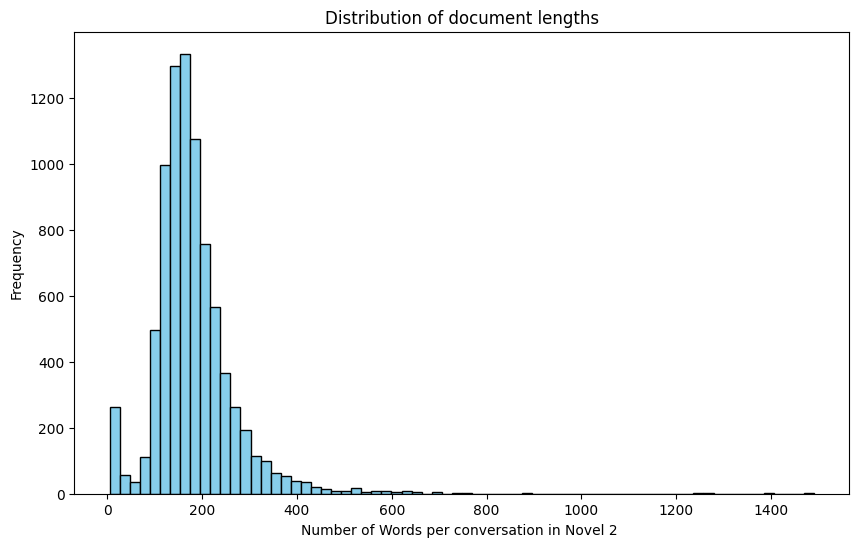

In [58]:
import matplotlib.pyplot as plt 

lengths = [
    len(sent.split()) for sent in df['text']
]

plt.figure(figsize=(10, 6)) 
plt.hist(lengths, bins=70, color='skyblue', edgecolor='black') 
plt.title("Distribution of document lengths")
plt.xlabel("Number of Words per conversation in Novel 2 ")
plt.ylabel("Frequency")
plt.savefig("distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [59]:
import pandas as pd
pd.Series(lengths).describe()

count    8330.000000
mean      180.921849
std        85.311539
min         5.000000
25%       135.000000
50%       168.000000
75%       212.000000
max      1491.000000
dtype: float64

In [60]:
df.to_csv('al_qa2d.csv' ,encoding = 'utf-8-sig')

# Augmentation 

In [61]:
df1 = pd.read_csv('/kaggle/working/al_qa2d.csv' ,  encoding = 'utf-8-sig')
df2 = pd.read_csv('/kaggle/working/amirat_a5er_alzaman.csv' ,  encoding = 'utf-8-sig')
df3 = pd.read_csv('/kaggle/working/gamila_wal_wahsh.csv' ,  encoding = 'utf-8-sig')
df4 = pd.read_csv('/kaggle/working/habibi_almaghol.csv' ,  encoding = 'utf-8-sig')
df5 = pd.read_csv('/kaggle/working/jana_al_hawa.csv' ,  encoding = 'utf-8-sig')
#df6 = pd.read_csv('/kaggle/working/set_el_hosn.csv' ,  encoding = 'utf-8-sig')
#df7 = pd.read_csv('/kaggle/working/set_el_hosn_2.csv' ,  encoding = 'utf-8-sig')

df = pd.concat([df1, df2, df3, df4, df5], axis=0, ignore_index=True)

In [62]:
df1.loc[10 , 'text']

'ادم رجع لورا و مثل الخوف: لا من قبليها و ربنا\nرحاب صرخت: انت بتهزر؟\nادم مسك إيديها الاتنين و حاول ميضحكش: طب ممكن تهدى؟\nرحاب صرخت اعلى و هي بتشد إيديها منه: متقوليش اهدى\nادم رفع حاجبه: طب ممكن متتعصبيش؟ كده اشيك؟ اهدى بقا خلينى اعرف انطق\nرحاب بتتنفس بعنف و هو سحبها و قعد على انتريه قصادهم: انتى عارفه طبيعة شغلى يا رحاب. عارفه من قبل ما نتجوز. من ايام ما كنا قرايب و جيران و بس. و لا نسيتى؟\nرحاب وقفت بغضب: انت اللى نسيت انك متجوز مش انا اللى نسيت انك ظابط. نسيت انك متجوز و يا عالم نسيت نفسك و لا لسه\nادم بإستخفاف: لاء نسيت اجيب حباية الضغط من ع الحبل قبل ما اجى\nرحاب بغضب زقته: انت ايه يا اخى؟ ده انا نسيت انى متجوزه من كتر حججك و اعذار شغلك اللى بسمعها\nادم وقف قرب منها ف محاولة هدوء: رحاب محصلش حاجه لكل ده. انا كنت ف عمليه تبع شغلى و معرّفك و.'

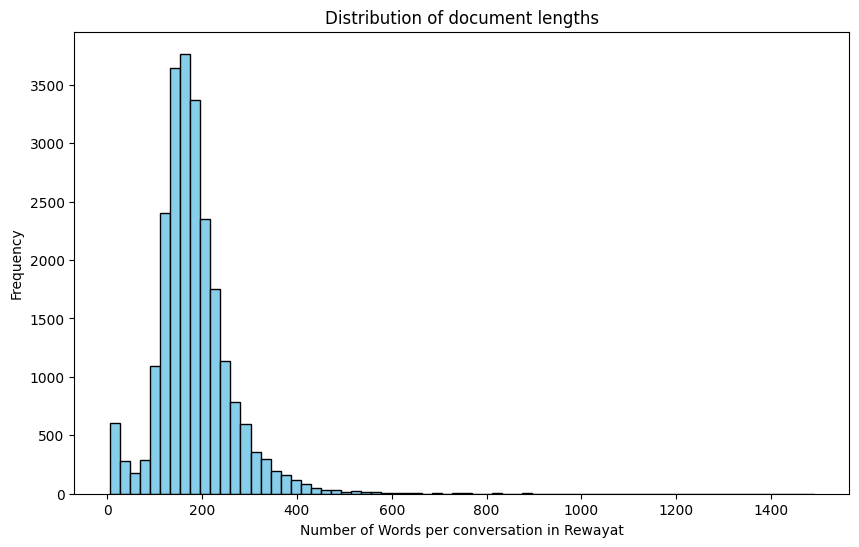

In [63]:
import matplotlib.pyplot as plt 

lengths = [
    len(sent.split()) for sent in df['text']
]

plt.figure(figsize=(10, 6)) 
plt.hist(lengths, bins=70, color='skyblue', edgecolor='black') 
plt.title("Distribution of document lengths")
plt.xlabel("Number of Words per conversation in Rewayat")
plt.ylabel("Frequency")
plt.savefig("distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [64]:
pd.Series(lengths).describe()

count    23683.000000
mean       182.105434
std         76.860642
min          5.000000
25%        139.000000
50%        172.000000
75%        215.000000
max       1491.000000
dtype: float64

In [65]:
df_filtered = df[df['text'].str.split().str.len() <= 500].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Original rows: {len(df)}")
print(f"Filtered rows: {len(df_filtered)}")
print(f"Dropped {len(df) - len(df_filtered)} rows with more than 500 words.")

Original rows: 23683
Filtered rows: 23582
Dropped 101 rows with more than 500 words.


In [66]:
import seaborn as sns

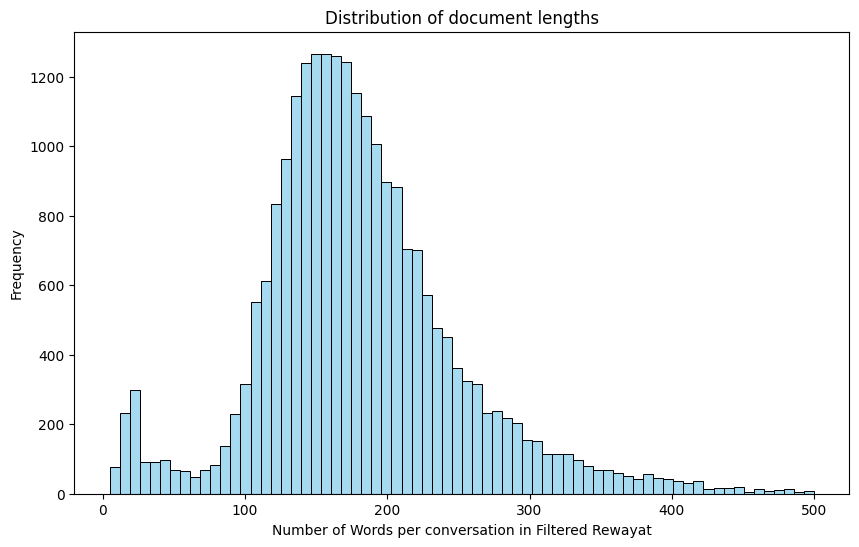

In [67]:
lengths = [
    len(sent.split()) for sent in df_filtered['text']
]

plt.figure(figsize=(10, 6)) 
sns.histplot(lengths, bins=70, color='skyblue') 
plt.title("Distribution of document lengths")
plt.xlabel("Number of Words per conversation in Filtered Rewayat")
plt.ylabel("Frequency")
plt.savefig("distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [68]:
pd.Series(lengths).describe()

count    23582.000000
mean       180.207786
std         70.439852
min          5.000000
25%        139.000000
50%        172.000000
75%        214.000000
max        500.000000
dtype: float64

In [70]:
df_filtered.to_csv('Dataset.csv' , encoding = 'utf-8-sig')
len(df_filtered)

23582

In [73]:
df_filtered = df_filtered.sample(frac=1, random_state=42).reset_index(drop=True)
df_filtered = df_filtered.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df_filtered

In [74]:
len(df_filtered)

23582

In [75]:
df_filtered.to_csv('Rewayat_data_shuffled.csv' , encoding = 'utf-8-sig')

# Cleaning

In [ ]:
import re
import pandas as pd

def is_garbage_text(text):
    if not isinstance(text, str):
        return True
    
    text_clean = text.strip()
    menu_keywords = ["☰", "روائيون", "قصص رومانسية", "روايات صعيدية", "قصص مخيفة", "جميع الفصول", "روايات مشابهة"]
    if any(keyword in text_clean for keyword in menu_keywords):
        return True
    
    footer_keywords = ["Designed by", "©", "MP Software"]
    if any(keyword in text_clean for keyword in footer_keywords):
        return True

    meta_patterns = r"(رواية|الفصل|الكاتبة|الجزء|الكاتب)"
    lines = [line.strip() for line in text_clean.split('\n') if line.strip()]
    
    if len(lines) > 0:
        meta_line_count = sum(1 for line in lines if re.search(meta_patterns, line))
        # If more than 60% of the lines in this chunk are metadata/navigation headers, drop it
        if (meta_line_count / len(lines)) > 0.60:
            return True
            
    return False

garbage_mask = df_filtered['text'].apply(is_garbage_text)
df_clean = df_filtered[~garbage_mask].copy().reset_index(drop=True)

print(f"Original rows: {len(df_filtered)}")
print(f"Cleaned rows remaining: {len(df_clean)}")
print(f"Removed {len(df_filtered) - len(df_clean)} rows of menu/header garbage.")

Original rows: 23582
Cleaned rows remaining: 21918
Removed 1664 rows of menu/header garbage.


In [77]:
df_clean.loc[1 , 'text']

'مؤمن وضح: مردش عليا، بس كلمت سيف وطلبت منه يكلمه. مش عارف رد عليه ولا لأ.!؟\nسيطر الصمت شوية، بعدها مؤمن علق: أمل! كريم مستحيل يخون نفسه قبل ما يخونك، ما يعملهاش. لو ألف تحليل قالوا إبنه، برضه هفضل مصدق إنه ما يعملهاش.\nجزء منها كان مصدق كلام مؤمن، لكن جزء تاني كان مليان شك: طيب، التحليل إزاي بيقول إبنه؟ إيه تحليلك يا مؤمن؟\nرد بحيرة: معرفش، معنديش إجابة. بس هو قال معملهاش، وكلامه بالنسبالي مصدق، لا يحتمل حتى مجرد الشك. أمل، كريم ما يكدبش أبدًا، فما بالك بخيانة؟ إحنا بنتكلم في أكبر الكبائر، ده ما بيسلمش على واحدة مش من محارمه، هيرتكب معصية زي دي؟\nأمل تنهدت: إنت بتقولي الكلام ده ليه يا مؤمن؟ متخيل إني مش عارفاه؟ مش عارفة كريم وأخلاقه؟\nمؤمن دافع بحماس: عارف إنك عارفة، بس المصيبة اللي إنتو فيها كبيرة. يمكن تكوني محتاجة حد معاكِ بيحب كريم زيك وأكتر يقولك إنه ما يعملهاش. يقولك إنه بيحبك إنتِ وبس. لا، مش بس بيحبك، كريم بيعشقك. كريم قال لي، لو أنا مكانك وأمل مكان نور، هنفذ رغبتها وهديها فرصة، لأني مش متخيل أعيش حياة هي مش فيها. كريم بيحبك بشكل معرفتش أحبه لنور، ويمكن علشان كده إحنا الاتنين

In [78]:
import os
import camel_tools 
from camel_tools.utils.normalize import normalize_unicode
#to normalize 'alef' variants
from camel_tools.utils.normalize import normalize_alef_maksura_ar
#to normalize 'ya2' variants
from camel_tools.utils.normalize import normalize_alef_ar
#to normalize 'teh marbota' variants
from camel_tools.utils.normalize import normalize_teh_marbuta_ar
#to remove diacritical marks
from camel_tools.utils.dediac import dediac_ar
from tqdm import tqdm

In [81]:
def clean(df , col):
    #df = df.drop_duplicates(subset=[col])
    #df = df.dropna(subset=[col])
    
    df[col] = df[col].fillna("").astype(str)
    df = df.reset_index(drop=True)
    for i in tqdm(range(len(df))):
        sentence = df.loc[i , col]
        sentence = normalize_unicode(sentence)
        sentence = dediac_ar(sentence)
        sentence = normalize_alef_maksura_ar(sentence)
        sentence = normalize_alef_ar(sentence)
        sentence = normalize_teh_marbuta_ar(sentence)
        #this regex will remove all non-Arabic letters and non-space characters
        sentence = re.sub(
    r'[^\u0600-\u06FF\u060C\u061B\u061F\u066D!\"#$%&\'()*+,\-./:;<=>?@\[\\\]^_`{|}~\s]',
    '',
    sentence,
    flags=re.UNICODE)
        df.loc[i , col] = sentence
    return df  

In [86]:
df_clean_extra = clean(df_clean , 'text')

100%|██████████| 21918/21918 [00:25<00:00, 856.77it/s]


In [87]:
df_clean_extra.head()

,Unnamed: 0,source_file,chunk_index,text
0,2960,jana_al_hawa_ch_3.txt,84,اتعدلت وبصتله: تحب تعمل ايه؟\nبعد شعرها عن وشه...
1,7252,jana_al_hawa_ch_59.txt,48,مؤمن وضح: مردش عليا، بس كلمت سيف وطلبت منه يكل...
2,7636,jana_al_hawa_ch_61.txt,4,عز بدفاع واهن: ما طلبتش منك تضحي بحياتك.\nسيف ...
3,8902,jana_al_hawa_ch_69.txt,36,كامل تراجع: نغير السؤال، هل سبق لك الزواج؟ (ال...
4,912,jana_al_hawa_ch_15.txt,138,هزت راسها بموافقه وما ردتش.\nبالليل امل قاعده ...


In [88]:
df_clean_extra.loc[0 , 'text']

'اتعدلت وبصتله: تحب تعمل ايه؟\nبعد شعرها عن وشها ورد بتفكير: كنت هقول ننزل حمام السباحه بس مش هينفع - اقترح فجاه - تعالي ننزل نسهر في اي مكان برا\nبصت لساعته في ايده: الساعه  يا سيف\nابتسم وقام وشدها: قومي هسهرك سهره حلوه، الايام دي نصيعها انا وانت برا قومي البسي\nقامت معاه و وقفت محتاره قدام هدومها فبصلها: محتاره ليه؟\nبصتله وردت: البس ايه؟ هنروح فين؟ البس حاجه عاديه؟ البس جينز، فستان سهره؟\nقرب منها وحط ايديه حواليها وهو وراها: بقولك نسهر يا حبيبتي، يعني اكيد فستان سهره\nقلب في دولابها واختار معاها فستان ازرق رقيق وسابها تلبس براحتها وهو يجهز.\nبعد شويه دخل يطمئن عليها كانت بتحط اخر لمسات في الميكاب وقف منبهر بجمالها، كان متخيل انه هيتعود علي جمالها بس كل يوم بيتاكد انه غلطان، لاحظت نظراته فسالته: في حاجه يا حبيبي ولا ايه؟ اتاخرت اوي؟\nابتسم بهدوء: لا يا روحي انا يدوب خلصت، قدامك كتير؟'

In [130]:
def remove_repeated_chars(text):
    cleaned = re.sub(r'(.)\1{2,}', r'\1', text)
    return cleaned

df_clean_extra['codafied_text'] = df_clean_extra['codafied_text'].apply(remove_repeated_chars)

In [109]:
df['codafied_text'] = df['codafied_text'].apply(remove_repeated_chars)

In [92]:
df_clean_extra.loc[1 , 'text']

'مؤمن وضح: مردش عليا، بس كلمت سيف وطلبت منه يكلمه. مش عارف رد عليه ولا لا.!؟\nسيطر الصمت شويه، بعدها مؤمن علق: امل! كريم مستحيل يخون نفسه قبل ما يخونك، ما يعملهاش. لو الف تحليل قالوا ابنه، برضه هفضل مصدق انه ما يعملهاش.\nجزء منها كان مصدق كلام مؤمن، لكن جزء تاني كان مليان شك: طيب، التحليل ازاي بيقول ابنه؟ ايه تحليلك يا مؤمن؟\nرد بحيره: معرفش، معنديش اجابه. بس هو قال معملهاش، وكلامه بالنسبالي مصدق، لا يحتمل حتي مجرد الشك. امل، كريم ما يكدبش ابدا، فما بالك بخيانه؟ احنا بنتكلم في اكبر الكبائر، ده ما بيسلمش علي واحده مش من محارمه، هيرتكب معصيه زي دي؟\nامل تنهدت: انت بتقولي الكلام ده ليه يا مؤمن؟ متخيل اني مش عارفاه؟ مش عارفه كريم واخلاقه؟\nمؤمن دافع بحماس: عارف انك عارفه، بس المصيبه اللي انتو فيها كبيره. يمكن تكوني محتاجه حد معاك بيحب كريم زيك واكتر يقولك انه ما يعملهاش. يقولك انه بيحبك انت وبس. لا، مش بس بيحبك، كريم بيعشقك. كريم قال لي، لو انا مكانك وامل مكان نور، هنفذ رغبتها وهديها فرصه، لاني مش متخيل اعيش حياه هي مش فيها. كريم بيحبك بشكل معرفتش احبه لنور، ويمكن علشان كده احنا الاتنين سي

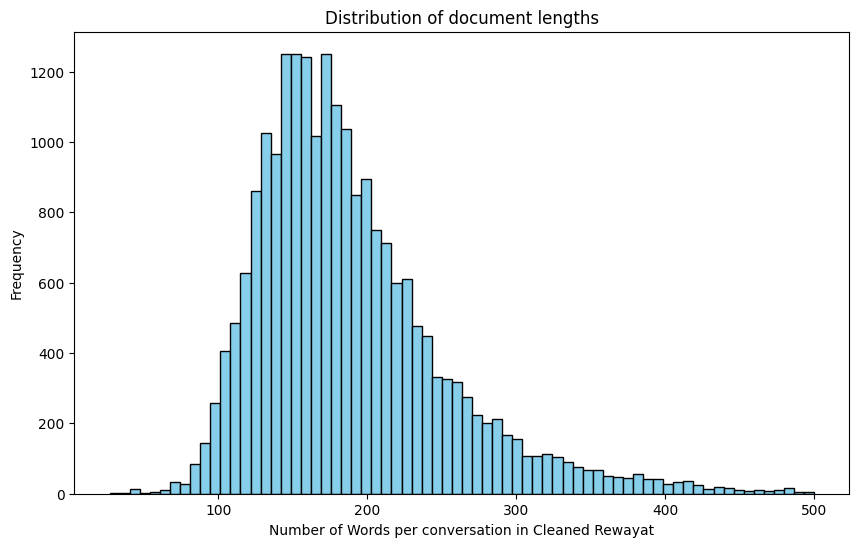

In [124]:
lengths = [
    len(sent.split()) for sent in df_clean_extra['text']
]

plt.figure(figsize=(10, 6)) 
plt.hist(lengths, bins=70, color='skyblue', edgecolor='black') 
plt.title("Distribution of document lengths")
plt.xlabel("Number of Words per conversation in Cleaned Rewayat")
plt.ylabel("Frequency")
plt.savefig("distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [125]:
pd.Series(lengths).describe()

count    21918.000000
mean       188.266858
std         63.606189
min         27.000000
25%        144.000000
50%        175.000000
75%        218.000000
max        500.000000
dtype: float64

In [95]:
df_clean_extra.columns

Index(['Unnamed: 0', 'source_file', 'chunk_index', 'text'], dtype='object')

In [96]:
df_clean_extra = df_clean_extra.drop(columns = ['Unnamed: 0'])
df_clean_extra.head()

,source_file,chunk_index,text
0,jana_al_hawa_ch_3.txt,84,اتعدلت وبصتله: تحب تعمل ايه؟\nبعد شعرها عن وشه...
1,jana_al_hawa_ch_59.txt,48,مؤمن وضح: مردش عليا، بس كلمت سيف وطلبت منه يكل...
2,jana_al_hawa_ch_61.txt,4,عز بدفاع واهن: ما طلبتش منك تضحي بحياتك.\nسيف ...
3,jana_al_hawa_ch_69.txt,36,كامل تراجع: نغير السؤال، هل سبق لك الزواج؟ (ال...
4,jana_al_hawa_ch_15.txt,138,هزت راسها بموافقه وما ردتش.\nبالليل امل قاعده ...


In [115]:
df_clean_extra

,source_file,chunk_index,text
0,jana_al_hawa_ch_3.txt,84,اتعدلت وبصتله: تحب تعمل ايه؟\nبعد شعرها عن وشه...
1,jana_al_hawa_ch_59.txt,48,مؤمن وضح: مردش عليا، بس كلمت سيف وطلبت منه يكل...
2,jana_al_hawa_ch_61.txt,4,عز بدفاع واهن: ما طلبتش منك تضحي بحياتك.\nسيف ...
3,jana_al_hawa_ch_69.txt,36,كامل تراجع: نغير السؤال، هل سبق لك الزواج؟ (ال...
4,jana_al_hawa_ch_15.txt,138,هزت راسها بموافقه وما ردتش.\nبالليل امل قاعده ...
...,...,...,...
21913,jana_al_hawa_ch_30.txt,3,مايا بغيظ: طيب اتصلي بها اعرفي غابت ليه مش انت...
21914,al_qa2d_2_ch_33.txt,83,محاسن: عليكي نوور. هتعرفي بقا و لا هتتغابي؟\nر...
21915,jana_al_hawa_ch_32.txt,4,بص ناحيته: مع مين؟\nسبيدو: مراتك؟ يعني مش عايز...
21916,jana_al_hawa_ch_31.txt,55,هاله دموعها لمعت وسكتت وجواها كلام كتير عايزه ...


In [97]:
df_clean_extra.to_csv('cleaned_text_Rewayat.csv' , encoding = 'utf-8-sig')

In [ ]:
from datasets import Dataset 
from huggingface_hub import upload_folder , login
login(token = '')
ds = Dataset.from_pandas(df_clean_extra)
ds.push_to_hub("RanaGaber/Egyptian_Rewayat")

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

model.safetensors:   0%|          | 0.00/539M [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/RanaGaber/Egyptian_Rewayat/commit/0429ada7b32e03879f2239f74db99183aa260815', commit_message='Upload dataset', commit_description='', oid='0429ada7b32e03879f2239f74db99183aa260815', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/RanaGaber/Egyptian_Rewayat', endpoint='https://huggingface.co', repo_type='dataset', repo_id='RanaGaber/Egyptian_Rewayat'), pr_revision=None, pr_num=None)

# Normalization

In [98]:
!pip install camel_tools

In [99]:
import os
import shutil

if os.path.exists('text-editing'):
    shutil.rmtree('text-editing')
!git clone https://github.com/CAMeL-Lab/text-editing.git


if os.path.exists('gec'): shutil.rmtree('gec')
if os.path.exists('edits'): shutil.rmtree('edits')

shutil.move('text-editing/gec', 'gec')
shutil.move('text-editing/edits', 'edits')

shutil.rmtree('text-editing')

print("Code successfully moved to top-level. You can now import without errors.")

Cloning into 'text-editing'...
remote: Enumerating objects: 2242, done.
remote: Counting objects: 100% (385/385), done.
remote: Compressing objects: 100% (263/263), done.
remote: Total 2242 (delta 206), reused 241 (delta 99), pack-reused 1857 (from 1)
Receiving objects: 100% (2242/2242), 60.08 MiB | 21.80 MiB/s, done.
Resolving deltas: 100% (993/993), done.
Code successfully moved to top-level. You can now import without errors.


In [100]:
from gec.tag import rewrite
from transformers import BertTokenizer, BertForTokenClassification
import torch
import torch.nn.functional as F

tokenizer = BertTokenizer.from_pretrained('CAMeL-Lab/text-editing-coda')
model = BertForTokenClassification.from_pretrained('CAMeL-Lab/text-editing-coda')

text = 'هو لسه مجاش ولسه مبيردش ع التليفون'.split()

tokenized_text = tokenizer(text, return_tensors="pt", is_split_into_words=True)

with torch.no_grad():
    logits = model(**tokenized_text).logits
    preds = F.softmax(logits.squeeze(), dim=-1)
    preds = torch.argmax(preds, dim=-1).cpu().numpy()
    edits = [model.config.id2label[p] for p in preds[1:-1]]
    assert len(edits) == len(tokenized_text['input_ids'][0][1:-1])

print(edits)
subwords = tokenizer.convert_ids_to_tokens(tokenized_text['input_ids'][0][1:-1])
output_sent = rewrite(subwords=[subwords], edits=[edits])[0][0]
print(output_sent) 

/kaggle/working/gec/utils/postprocess.py:62: SyntaxWarning: invalid escape sequence '\d'
  pnx_re = re.compile(r'([' + re.escape(puncs) + '])(?!\d)')


tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/539M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: CAMeL-Lab/text-editing-coda
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


['K*', 'K*', 'K*', 'K*', 'K*', 'K*', 'KI_[ا ]K*', 'K*', 'K*', 'K*', 'MK*']
هو لسه مجاش ولسه ما بيردش عالتليفون


In [102]:
from datasets import load_dataset
from huggingface_hub import upload_folder , login

ds = load_dataset("RanaGaber/Egyptian_Rewayat")

README.md:   0%|          | 0.00/377 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/19.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/21918 [00:00<?, ? examples/s]

In [103]:
df = ds['train'].to_pandas()
df.head()

,source_file,chunk_index,text
0,jana_al_hawa_ch_3.txt,84,اتعدلت وبصتله: تحب تعمل ايه؟\nبعد شعرها عن وشه...
1,jana_al_hawa_ch_59.txt,48,مؤمن وضح: مردش عليا، بس كلمت سيف وطلبت منه يكل...
2,jana_al_hawa_ch_61.txt,4,عز بدفاع واهن: ما طلبتش منك تضحي بحياتك.\nسيف ...
3,jana_al_hawa_ch_69.txt,36,كامل تراجع: نغير السؤال، هل سبق لك الزواج؟ (ال...
4,jana_al_hawa_ch_15.txt,138,هزت راسها بموافقه وما ردتش.\nبالليل امل قاعده ...


In [118]:
from tqdm import tqdm
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

def run_codafication(text):
    if not isinstance(text, str):
        return text
    lines = text.split('\n')
    processed_lines = []
    
    for line in lines:
        if not line.strip():
            processed_lines.append(line)
            continue
            
        words = line.split()
        chunk_size = 200
        chunks = [words[i:i + chunk_size] for i in range(0, len(words), chunk_size)]
        full_output = []
        for chunk in chunks:
            tokenized_text = tokenizer(chunk, return_tensors="pt", is_split_into_words=True)
            
            if tokenized_text['input_ids'].shape[1] > 512:
                tokenized_text = {k: v[:, :512] for k, v in tokenized_text.items()}
                
            input_gpu = {k: v.to(device) for k, v in tokenized_text.items()}
                
            with torch.no_grad():
                logits = model(**input_gpu).logits
                preds = F.softmax(logits.squeeze(), dim=-1)
                
                if preds.dim() == 1:
                    preds = preds.unsqueeze(0)
                    
                preds = torch.argmax(preds, dim=-1).cpu().numpy()
                edits = [model.config.id2label[p] for p in preds[1:-1]]
                
                subwords = tokenizer.convert_ids_to_tokens(tokenized_text['input_ids'][0][1:-1])
                corrected_chunk = rewrite(subwords=[subwords], edits=[edits])[0][0]
                full_output.append(corrected_chunk)
        
        processed_lines.append(" ".join(full_output))
        
    return "\n".join(processed_lines)

df_clean_extra['codafied_text'] = df_clean_extra['text'].apply(run_codafication)

In [135]:
df_clean_extra.to_csv('codafied_rowayat.csv' , encoding = 'utf-8-sig')

In [119]:
df_clean_extra.head()

,source_file,chunk_index,text,codafied_text
0,jana_al_hawa_ch_3.txt,84,اتعدلت وبصتله: تحب تعمل ايه؟\nبعد شعرها عن وشه...,اتعدلت وبصتله : تحب تعمل ايه؟\nبعد شعرها عن وش...
1,jana_al_hawa_ch_59.txt,48,مؤمن وضح: مردش عليا، بس كلمت سيف وطلبت منه يكل...,مؤمن وضح : مردش عليا ، بس كلمت سيف وطلبت منه ي...
2,jana_al_hawa_ch_61.txt,4,عز بدفاع واهن: ما طلبتش منك تضحي بحياتك.\nسيف ...,عز بدفاع واهن : ما طلبتش منك تضحي بحياتك.\nسيف...
3,jana_al_hawa_ch_69.txt,36,كامل تراجع: نغير السؤال، هل سبق لك الزواج؟ (ال...,كامل تراجع : نغير السؤال ، هل سبق لك الزواج؟ (...
4,jana_al_hawa_ch_15.txt,138,هزت راسها بموافقه وما ردتش.\nبالليل امل قاعده ...,هزت راسها بموافقة وما ردتش.\nبالليل امل قاعدة ...


In [131]:
import re

def has_repeated_chars(text):
    return bool(re.search(r'(.)\1{2,}', text))
df_clean_extra['has?'] = df_clean_extra['codafied_text'].apply(has_repeated_chars)
df_clean_extra['has?'].sum()

np.int64(0)

In [133]:
df_clean_extra  = df_clean_extra .drop(columns = 'has?')

In [128]:
repeat = df_clean_extra[df_clean_extra['has?'] == True]

In [129]:
repeat.to_csv('data.csv' , encoding = 'utf-8-sig')

In [134]:
ds = Dataset.from_pandas(df_clean_extra)
                        
ds.push_to_hub('RanaGaber/Egyptian_Rewayat')

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/RanaGaber/Egyptian_Rewayat/commit/6c813792902066ee01972e2e14a4eb6c88ce78f0', commit_message='Upload dataset', commit_description='', oid='6c813792902066ee01972e2e14a4eb6c88ce78f0', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/RanaGaber/Egyptian_Rewayat', endpoint='https://huggingface.co', repo_type='dataset', repo_id='RanaGaber/Egyptian_Rewayat'), pr_revision=None, pr_num=None)

In [113]:
df.loc[0 , 'codafied_text']

'داغر قلع الجاكيت بتاعة وحفر ضوافرة في القماش بتاع الجاكية ولفه حوالين ايديه ورجع لورا وبخطوات سريعة منه بقي يمسك السلك الكهربة كانت بتمسك في جسمه بس من كتر سرعته بقي بيحفر بضوافره في السور ونط بسرعة وطلع للناحيه الثانية واول ما نزل نزل راسه لتحت هدير بتبص لاقت اطراف صوابعه كلها جايبة دم هدير داغر صوابعك داغر ما تهتميش بيها قولي لي علي مكان الطفلة بسرعه هدير خل لي بالك ممكن يكون عليها الف حراسة داغر بسرعه ياهدير مفيش وقت الثلج والعاصفه اللي كانت موجودة كانت مساعده داغر جدا البودي جاردات من كتر ما كانت الدنيا ثلج وبيمشوا علي ثلج حرفيا كانوا بيرفعوا رجليهم من علي الثلج بالعافية انما داغر فهو متعود علي كده ده غير حركته السريعة هدير خلي بالك فيه شباك قدامك تقدر تكسر الازاز وتدخل منه داغر كسر الازاز بايديه ودخل داغر حط ايده علي السماعه اللي في ودنه فيه حاجة غلط ياهدير هدير اي اللي ممكن يكون غلط داغر مش فاهم بس الدخول كان سهل جدا انا حاسس ان فيه لعبه في الموضوع في حاجة غلط ولسه بيكمل الكلمه لقي ار بي جي داخل عليه'

In [114]:
df = pd.read_csv('/kaggle/input/datasets/ranagaber1111/codafied-data/codafied_rowayat.csv' , encoding = 'utf-8-sig')
df.head()

,Unnamed: 0,source_file,chunk_index,text,codafied_text
0,0,gamila_wal_wahsh_ch_15.txt,8,داغر قلع الجاكيت بتاعه وحفر ضوافره في القماش ب...,داغر قلع الجاكيت بتاعة وحفر ضوافرة في القماش ب...
1,1,habibi_almaghol_chapter_6.txt,22,محمد هيا كانت كويسه ايه اللي حصل تاني؟ وفاء ات...,محمد هي كانت كويسة ايه اللي حصل ثاني؟ وفاء اتك...
2,2,amirat_a5er_alzaman_chapter_30.txt,8,تحدث اليها باحترام قائلا لها لو سمحتي انا عايز...,تحدث اليها باحترام قائلا لها لو سمحتي انا عايز...
3,3,jana_al_hawa_ch_75.txt,66,وبناء عليه، تامر المحكمه بتنفيذ الحكم فورا، ور...,وبناء عليه ، تامر المحكمة بتنفيذ الحكم فورا ، ...
4,4,jana_al_hawa_ch_2.txt,23,بصلها بتهكم طيب ونور؟ ما احنا برضه اتحرمنا من ...,باصلها بتهكم طيب ونور؟ ما احنا برضه اتحرمنا من...


In [112]:
from datasets import Dataset 
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/ranagaber1111/codafied-data/codafied_rowayat.csv' , encoding = 'utf-8-sig')
ds = Dataset.from_pandas(df)
ds.push_to_hub('RanaGaber/Egyptian_Rewayat')

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/datasets/RanaGaber/Egyptian_Rewayat/commit/b242356afdbf2b4ef6922b27d785c2b0ddb581b7', commit_message='Upload dataset', commit_description='', oid='b242356afdbf2b4ef6922b27d785c2b0ddb581b7', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/RanaGaber/Egyptian_Rewayat', endpoint='https://huggingface.co', repo_type='dataset', repo_id='RanaGaber/Egyptian_Rewayat'), pr_revision=None, pr_num=None)